# 04 · Recreating the MACE architecture, block by block: original MACE **and** `xnns`

This tutorial walks through the [MACE](https://github.com/ACEsuit/mace) architecture
one block at a time, and for **every block builds it twice**, once with the
**original `mace-torch`** (ACEsuit/mace, our ground truth) and once with the
**`xnns`** re-implementation (`xnns.gnn.models.mace`), then checks that the two
agree to machine precision.

The goal is twofold:

1. **Understand MACE.** MACE is a message-passing interatomic potential that builds
   *equivariant, many-body* atomic features and maps them to an energy. We expose
   each internal block and its defining equation.
2. **Show `xnns` reproduces MACE exactly.** `xnns` reuses the same maths (real
   Clebsch–Gordan coupling, learned symmetric contraction) with no `mace-torch`
   dependency, only `e3nn`. By the end we transplant a *whole* trained-shape MACE
   from `mace-torch` into `xnns` and reproduce its **energy and forces to ~1e-15**.

> **Credit.** The pedagogy, equations and figures follow the excellent
> *"Deep Dive into the MACE Architecture"* developer tutorial by **Will Baldwin**,
> based on material by **Ilyes Batatia** (University of Cambridge). The
> dual-implementation comparison against `xnns` is the new contribution here.
>
> **References.**
> [MACE (NeurIPS 2022)](https://proceedings.neurips.cc/paper_files/paper/2022/file/4a36c3c51af11ed9f34615b81edb5bbc-Paper-Conference.pdf) |
> [The Design Space of E(3)-Equivariant Atom-Centred Interatomic Potentials (Multi-ACE)](https://doi.org/10.48550/arXiv.2205.06643) |
> [MACE-OFF](https://doi.org/10.1063/5.0155322) |
> [code](https://github.com/ACEsuit/mace) | [docs](https://mace-docs.readthedocs.io/)

## 0. Setup

This notebook needs the `examples` extra (installs `mace-torch`, `e3nn`, `ase`,
`matplotlib`, …) on top of `xnns`:

```bash
pip install -e ".[examples]"      # or:  uv sync --extra examples
```

`mace-torch==0.3.16` pins `e3nn==0.4.4`; `xnns` runs fine on that pin. We use
`float64` throughout: MACE's default, and required for a bit-exact comparison.

In [1]:
import warnings, logging
warnings.filterwarnings("ignore")                     # e3nn/torch.load + TorchScript noise
logging.getLogger("cuequivariance").setLevel(logging.ERROR)

import numpy as np
import torch
torch.set_default_dtype(torch.float64)                # MACE default; needed for exact match
torch.manual_seed(0)

from e3nn import o3
import matplotlib.pyplot as plt
%matplotlib inline

import xnns, mace, e3nn
print("xnns :", xnns.__version__)
print("mace :", mace.__version__, "(original ACEsuit/mace — ground truth)")
print("e3nn :", e3nn.__version__)
print("torch:", torch.__version__, "| CUDA:", torch.cuda.is_available())

xnns : 0.1.0
mace : 0.3.16 (original ACEsuit/mace — ground truth)
e3nn : 0.4.4
torch: 2.5.1+cu121 | CUDA: True


<img src="figures/sketch.png" alt="MACE: most of the effort is feature construction"/>

MACE is a function that takes an atomic environment and returns an energy.
In classical ML potentials, *designing features* and *fitting* are separate steps;
in MACE they are blended. As the sketch shows, **most of the weights and most of the
compute build the atomic features**; once you have them, the energy is a relatively
simple learnable function of those features.

Below we open up the feature construction and rebuild it, block by block, in both
packages.

## The MACE architecture at a glance

<img src="figures/mace_architecture.png" alt="Schematic of the MACE architecture"/>

The key steps, repeated for each of $T$ message-passing layers indexed by
$t = 1, \dots, T$ (`num_interactions` $= T$):

1. **Embedding.** Turn the structure into initial features: a per-element node feature
   $h^{(0)}_i$ for each atom $i$, plus per-edge length (radial) and direction (spherical
   harmonic) features.
2. **Feature construction.**
   - **Interaction**: pool information from an atom's neighbours into a 2-body message,
     the *atomic basis* $A_i^{(t)}$.
   - **Product**: raise $A_i^{(t)}$ to higher body order via symmetric tensor products,
     giving the many-body features $B_i^{(t)}$.
   - **Update**: mix $B_i^{(t)}$ (with a self-connection) into the new node features
     $h^{(t)}_i$.
3. **Readout.** Map the *invariant* part of $h^{(t)}_i$ to a per-atom site energy
   $E_i^{(t)}$.
4. **Repeat** over layers, then form the total energy by summing every site energy plus
   a per-element reference energy $E_0$:
   $$ E \;=\; \sum_i \Big( E_0(z_i) + \sum_{t=1}^{T} E_i^{(t)} \Big), \qquad
      \mathbf{F}_i \;=\; -\,\frac{\partial E}{\partial \mathbf{r}_i}. $$

**Symbols used throughout.** $i$: atom index; $t$: layer index; $z_i$: chemical
element (atomic number) of atom $i$; $E_0(z)$: reference energy of an isolated atom of
element $z$; $\mathbf{r}_i$: position of atom $i$; $\mathbf{F}_i$: force on atom $i$
(obtained by automatic differentiation, so it is exactly the energy gradient).

## Default model parameters

We fix one small MACE configuration and build it in **both** packages. The `xnns`
config funnels through its `Config` dataclass; the `mace-torch` model takes the same
numbers as keyword arguments. Everything below reuses these two model objects.

In [2]:
from mace import data, modules, tools
import mace.modules as mm
from mace.modules.blocks import RealAgnosticResidualInteractionBlock as MIB

from xnns.common.data import structure_to_graph
from xnns.common.models import build_model, ForceStressOutput
from xnns.common.config import from_dict

# --- shared hyper-parameters ---
SPECIES = [1, 6, 8]            # H, C, O  -> the element channels
CUTOFF  = 3.0                  # r_max (Angstrom)
T       = 2                    # num_interactions (MACE layers)
NCH     = 8                    # num_channels (k)
MAX_ELL = 2                    # l_max of the edge spherical harmonics
MAX_L   = 1                    # l_max kept in the node features between layers
NRBF    = 8                    # number of Bessel radial functions
NPOLY   = 6                    # polynomial-cutoff smoothness
HID     = "8x0e+8x1o"          # hidden_irreps (8 channels of l=0 and l=1)
MLP     = "16x0e"              # final readout MLP width
RMLP    = [64, 64, 64]         # radial MLP hidden sizes (MACE default)
AVG     = 8.0                  # avg_num_neighbors (message normalisation)
CORR    = 3                    # correlation order (body order - 1)
E0      = np.array([-1.0, -3.0, -5.0])   # per-element reference energies

# --- xnns MACE ---
xcfg = from_dict({"model": {"name": "mace", "cutoff": CUTOFF, "n_features": NCH,
    "n_interactions": T, "extra": {"species": SPECIES, "max_ell": MAX_ELL,
    "max_L": MAX_L, "num_channels": NCH, "correlation": CORR, "num_bessel": NRBF,
    "num_polynomial_cutoff": NPOLY, "hidden_irreps": HID, "MLP_irreps": MLP,
    "radial_MLP": RMLP, "avg_num_neighbors": AVG, "atomic_energies": E0.tolist()}}})
xfull  = build_model(xcfg.model)
xmodel = ForceStressOutput(xfull, compute_forces=True).double()   # adds autograd forces

# --- original MACE ---
mmodel = mm.MACE(
    r_max=CUTOFF, num_bessel=NRBF, num_polynomial_cutoff=NPOLY, max_ell=MAX_ELL,
    interaction_cls=MIB, interaction_cls_first=MIB, num_interactions=T,
    num_elements=len(SPECIES), hidden_irreps=o3.Irreps(HID), MLP_irreps=o3.Irreps(MLP),
    atomic_energies=E0, avg_num_neighbors=AVG, atomic_numbers=SPECIES, correlation=CORR,
    gate=torch.nn.functional.silu, radial_MLP=RMLP, radial_type="bessel",
    use_reduced_cg=False, apply_cutoff=True).double()

n_x = sum(p.numel() for p in xfull.parameters())
n_m = sum(p.numel() for p in mmodel.parameters())
print(f"xnns  MACE parameters: {n_x}")
print(f"mace  MACE parameters: {n_m}")

cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


xnns  MACE parameters: 25656
mace  MACE parameters: 25456


### Copy the weights: `mace-torch` → `xnns`

The two models have the *same architecture*, so we can transplant every weight from
`mace-torch` into `xnns`. After this, any difference in a block's output is a genuine
implementation difference (not just different random init), so our block-by-block
"do they agree?" checks are meaningful.

(The two raw parameter counts differ by a little only because of *how* each stores the
per-element reference energies $E_0$: `xnns` uses an embedding table indexed by atomic
number, `mace-torch` a fixed buffer. The trainable network is identical, as the exact
energy match at the end confirms.)

The only non-trivial part is the **symmetric contraction**: `xnns` stores the
per-order weights in a single list `weights[0..corr-1]` (low → high order), whereas
`mace-torch` keeps the top order in `weights_max` and the rest in `weights` (high →
low). `transplant_sc` re-orders them.

In [3]:
def transplant_sc(xsc, msc, corr=CORR):
    # copy mace-torch SymmetricContraction weights into the xnns one
    with torch.no_grad():
        for c in range(len(xsc.contractions)):
            xc, mc = xsc.contractions[c], msc.contractions[c]
            xc.weights[corr - 1].copy_(mc.weights_max)               # top order nu=corr
            for nu in range(1, corr):
                xc.weights[nu - 1].copy_(mc.weights[corr - 1 - nu])  # lower orders

with torch.no_grad():
    xfull.node_embedding.load_state_dict(mmodel.node_embedding.linear.state_dict())
    for i in range(T):
        xfull.interactions[i].load_state_dict(mmodel.interactions[i].state_dict())
        transplant_sc(xfull.products[i].symmetric_contractions,
                      mmodel.products[i].symmetric_contractions, CORR)
        xfull.products[i].linear.load_state_dict(mmodel.products[i].linear.state_dict())
        xr, mr = xfull.readouts[i], mmodel.readouts[i]
        if "NonLinear" in type(mr).__name__:
            xr.linear_1.load_state_dict(mr.linear_1.state_dict())
            xr.linear_2.load_state_dict(mr.linear_2.state_dict())
        else:
            xr.linear.load_state_dict(mr.linear.state_dict())
    for z, e in zip(SPECIES, E0):
        xfull.atom_ref.weight[z] = float(e)                          # reference energies

# a small helper for the agreement checks below
def report(name, diff, tol=1e-10):
    tag = "OK " if diff <= tol else "!! "
    print(f"{tag}{name:<42} max|xnns - mace| = {diff:.2e}")

print("weights transplanted: mace-torch -> xnns")

weights transplanted: mace-torch -> xnns


# Spherical tensors and `e3nn`: the shared language

Both MACE and `xnns` represent directional information as **spherical tensors** and
manipulate them with [`e3nn`](https://e3nn.org/). The core fact: when you rotate a
direction $\mathbf{r}\to R\mathbf{r}$, the spherical harmonics $Y_l^m$ transform in a
known, linear way,

$$ Y_l^m(R\,\mathbf{r}) \;=\; \sum_{m'=-l}^{l} D^l_{mm'}(R)\; Y_l^{m'}(\mathbf{r}). $$

**Symbols.** $\mathbf{r}$: a 3D direction vector; $R$: a $3\times3$ rotation matrix;
$l = 0, 1, 2, \dots$: the *degree* (angular frequency) of the harmonic; $m = -l, \dots,
+l$: the *order* (there are $2l+1$ values of $m$ for each $l$); $Y_l^m(\mathbf{r})$:
the real spherical harmonic of degree $l$, order $m$; $D^l_{mm'}(R)$: the **Wigner
D-matrix**, the $(2l+1)\times(2l+1)$ matrix that mixes the order-$m$ components among
themselves under the rotation $R$.

The key consequence: a rotation only mixes components *within the same degree $l$*, and
never mixes different $l$'s. So the $l=0$ part ($D^0 = 1$) is left completely unchanged;
it is **rotation-invariant**. That is how we can always recover an invariant quantity
when we need one. Let's evaluate $Y_l^m$ for $l = 0, 1, 2$ on one vector.

In [4]:
spherical_harmonics = o3.SphericalHarmonics([0, 1, 2], normalize=True)
vector = torch.tensor([1.0, 0.2, 0.75])
print(spherical_harmonics(vector))

tensor([ 0.2821,  0.3860,  0.0772,  0.2895,  0.5113,  0.1364, -0.2918,  0.1023,
        -0.1491])


The array has 9 elements: $l=0$ (1 value), $l=1$ (3 values), $l=2$ (5 values),
concatenated as
$$[\,Y_0^0,\ \ Y_1^{-1}, Y_1^{0}, Y_1^{1},\ \ Y_2^{-2}, Y_2^{-1}, Y_2^{0}, Y_2^{1}, Y_2^{2}\,].$$
This $(l,m)$-flattened layout is how MACE (and `xnns`) store all equivariant arrays.

Now rotate the vector through a full turn and watch each component: the $l=0$ piece is
**constant** (invariant), while higher-$l$ pieces oscillate faster.

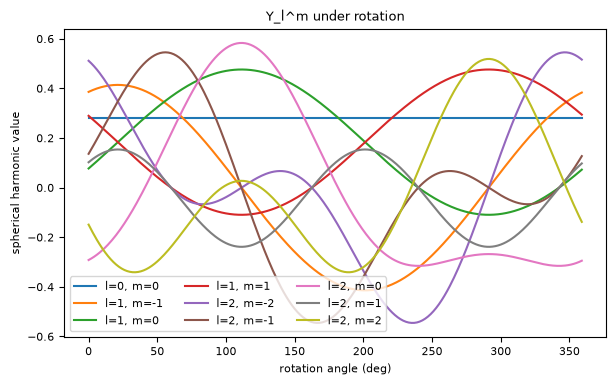

In [5]:
from scipy.spatial.transform import Rotation
axis = np.array([0, 0.7071, 0.7071])
vec  = np.array([1.0, 0.2, 0.75])
rots = [Rotation.from_rotvec(i * 2*np.pi * axis / 360).as_matrix() @ vec for i in range(360)]
vals = spherical_harmonics(torch.tensor(np.array(rots)))

labels = [f"l={l}, m={m}" for l in range(3) for m in range(-l, l+1)]
plt.figure(figsize=(7, 4))
plt.plot(vals.numpy(), label=labels)
plt.legend(ncol=3, fontsize=8); plt.xlabel("rotation angle (deg)")
plt.ylabel("spherical harmonic value"); plt.title("Y_l^m under rotation"); plt.show()

## Invariants that actually carry angular information

Just taking the $l=0$ piece of a single direction is uninformative (it is the same
constant for every direction). To build a *descriptive* invariant we combine two
spherical tensors with a **tensor product** $\otimes$, which `e3nn` performs while
correctly tracking all the $(l,m)$ bookkeeping:

$$ \big[A_l^m\big] \;\otimes\; \big[B_l^m\big] \;=\; \big[C_L^M\big]. $$

**Symbols.** $A_l^m$ and $B_l^m$: the two input spherical tensors (each a full set of
$(l,m)$ components, e.g. the spherical harmonics of two directions); $C_L^M$: the output
spherical tensor, indexed by its own degree $L$ and order $M$. Internally the product of
an input degree-$l_1$ part with an input degree-$l_2$ part is re-coupled (using
Clebsch–Gordan coefficients) into outputs whose degrees $L$ range over
$|l_1-l_2|,\dots,l_1+l_2$.

Because $C$ is *itself* a spherical tensor, its $L=0$ part is again rotation-invariant;
but, unlike the raw $l=0$ inputs, it now depends on the **angle between** $A$ and $B$.
This tensor product is the fundamental operation MACE is built on. Below we set up a
product of two $(l=0,1,2)$ tensors that outputs three invariant ($L=0$) numbers.

FullyConnectedTensorProduct(1x0e+1x1o+1x2e x 1x0e+1x1o+1x2e -> 3x0e | 9 paths | 9 weights)
(skipping tp.visualize(): needs older matplotlib than this environment)


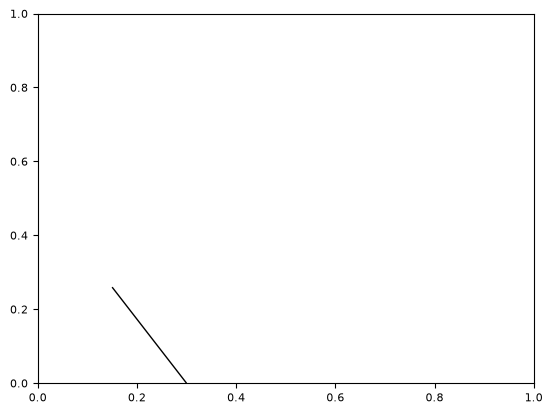

In [6]:
# a tensor product of two (l=0,1,2) arrays -> three invariant (l=0) outputs
tp = o3.FullyConnectedTensorProduct(
    o3.Irreps("1x0e+1x1o+1x2e"), o3.Irreps("1x0e+1x1o+1x2e"),
    o3.Irreps("3x0e"), internal_weights=False)
print(tp)
try:
    tp.visualize()                       # schematic of how inputs combine into outputs
except AttributeError:
    print("(skipping tp.visualize(): needs older matplotlib than this environment)")

In [7]:
np.random.seed(0)
v1 = np.random.randn(3); v1 /= np.linalg.norm(v1)
v2 = np.random.randn(3); v2 /= np.linalg.norm(v2)
w  = torch.arange(1, 10, 1, dtype=torch.float64)      # fixed weights, for illustration

def invariants(a, b):
    return tp(spherical_harmonics(torch.tensor(a)).unsqueeze(0),
              spherical_harmonics(torch.tensor(b)).unsqueeze(0), weight=w)

print("invariants          :", invariants(v1, v2).detach().numpy())

# rotate BOTH vectors by the same rotation -> invariants unchanged
R = Rotation.from_rotvec(77.7 * 2*np.pi * axis / 360).as_matrix()
print("invariants (rotated):", invariants(R @ v1, R @ v2).detach().numpy())

invariants          : [[0.25239444 0.34801136 0.44362828]]
invariants (rotated): [[0.25239444 0.34801136 0.44362828]]


The two rows match: the outputs are invariant to rotating the *whole* system, yet
(try changing the seed) they *do* change when the angle between the vectors changes.
That is exactly the property MACE needs.

# Recreating MACE feature construction, block by block

We now feed a **real molecule** (ethanol, C₂H₆O; it has exactly our H/C/O elements)
through the model and inspect each block, comparing `xnns` against `mace-torch` at
every step.

## 0. Data prep: structure → atoms + edges

MACE represents a structure as a list of atoms plus **edges** (pairs of atoms within
`r_max`). `mace-torch` uses `AtomicData`; `xnns` uses `AtomicGraph` via
`structure_to_graph`. Both build the same neighbour list.

In [8]:
from mace.tools import AtomicNumberTable, torch_geometric
from mace.data import AtomicData, Configuration
from ase.build import molecule

atoms = molecule("CH3CH2OH")                       # ethanol: 2 C, 1 O, 6 H
Z   = atoms.get_atomic_numbers()                   # (n_atoms,)
pos = atoms.get_positions()                        # (n_atoms, 3)

# --- xnns ---
graph = structure_to_graph({"pos": pos, "atomic_numbers": Z}, CUTOFF)

# --- original mace ---
zt   = AtomicNumberTable(SPECIES)
conf = Configuration(atomic_numbers=Z, positions=pos, properties={}, property_weights={})
ad   = AtomicData.from_config(conf, z_table=zt, cutoff=CUTOFF)
mbatch = next(iter(torch_geometric.dataloader.DataLoader([ad], batch_size=1)))

print("elements       :", Z.tolist())
print("xnns  nodes/edges:", graph.num_nodes, "/", graph.num_edges)
print("mace  nodes/edges:", mbatch.node_attrs.shape[0], "/", mbatch.edge_index.shape[1])
print("node_attrs (one-hot over [H,C,O]), first 3 atoms:\n",
      xfull.node_attr(graph.atomic_numbers)[:3].int().numpy())

elements       : [6, 6, 8, 1, 1, 1, 1, 1, 1]
xnns  nodes/edges: 9 / 58
mace  nodes/edges: 9 / 58
node_attrs (one-hot over [H,C,O]), first 3 atoms:
 [[0 1 0]
 [0 1 0]
 [0 0 1]]


`node_attrs` is a one-hot over the element set: `[1,0,0]`=H, `[0,1,0]`=C,
`[0,0,1]`=O. Edges are stored as `edge_index = [senders; receivers]`. From these we get
each edge's length and direction (both packages agree; `xnns` uses the convention
$\mathbf{r}_{ij} = \mathbf{r}_{\text{dst}} - \mathbf{r}_{\text{src}}$).

In [9]:
# edge vectors & lengths
vectors, lengths = modules.utils.get_edge_vectors_and_lengths(
    positions=mbatch["positions"], edge_index=mbatch["edge_index"], shifts=mbatch["shifts"])
print("mace  vectors/lengths:", tuple(vectors.shape), tuple(lengths.shape))
print("xnns  edge_vectors   :", tuple(graph.edge_vectors().shape))

mace  vectors/lengths: (58, 3) (58, 1)
xnns  edge_vectors   : (58, 3)


## 1. Embeddings

<img src="figures/embedding_layer.png" alt="The embedding block"/>

**Node embedding.** Each atom $i$ is given a length-$K$ feature vector that depends
only on its chemical element:

$$ h^{(0)}_{i,k00} \;=\; \sum_{z} W_{kz}\,\delta_{z\, z_i}. $$

Here,

- $h^{(0)}_{i,k00}$: the initial ($t=0$) feature of atom $i$ in channel $k$;
the trailing subscripts `00` mean degree $l=0$, order $m=0$ (these features are pure
scalars/invariants). 

- $k = 1, \dots, K$: the **channel** index; $K$ (`num_channels`) is
the fundamental descriptor width. 

- $z$: runs over the chemical elements. Thus, $z_i$ the element of atom $i$

- $\delta_{z\,z_i}$: the Kronecker delta (1 if $z = z_i$, else 0), so
the sum just *selects the column of $W$ for atom $i$'s element*

- $W_{kz}$: the learnable embedding weights. 

In code, $\delta_{z\,z_i}$ is the one-hot `node_attrs` and $W$ is a
linear layer.

**Edge embedding.** Each edge $i\!-\!j$ contributes two things: its *length*
$r_{ij} = \lVert \mathbf{r}_{ij}\rVert$ is expanded in Bessel radial functions multiplied
by a smooth polynomial cutoff $f_{\rm cut}$ (an **invariant** feature), and its
*direction* $\hat{\mathbf r}_{ij} = \mathbf{r}_{ij}/r_{ij}$ is turned into spherical
harmonics $Y_l^m(\hat{\mathbf r}_{ij})$ (an **equivariant** feature).

We compute all three embeddings in both packages and check they match. (Because the two
neighbour lists can order edges differently, we compare the spherical harmonics on a
*shared* set of edge vectors; see the code comment.)

In [10]:
# --- node embedding:  h0[i,k] = sum_z W[k,z] * delta(z, z_i) ---
na  = xfull.node_attr(graph.atomic_numbers)           # delta_{z z_i}: one-hot over [H,C,O], shape (N, 3)
h0x = xfull.node_embedding(na)                        # W @ delta  ->  (N, K=8) initial scalar features
h0m = mmodel.node_embedding(mbatch["node_attrs"])
report("node embedding  h^(0)", (h0x - h0m).abs().max().item())

# --- edge radial embedding ---
edge = xfull.edge_feat(graph)                        # dict: edge_sh, edge_radial, edge_length, edge_vec
mr, _ = mmodel.radial_embedding(lengths, mbatch["node_attrs"], mbatch["edge_index"], zt.zs)
report("radial embedding  R_n(r)*f_cut(r)", (edge["edge_radial"] - mr).abs().max().item())

# --- edge spherical harmonics (compare on the SAME vectors) ---
ir_sh  = o3.Irreps.spherical_harmonics(MAX_ELL)      # 1x0e+1x1o+1x2e
sh_x   = o3.spherical_harmonics(ir_sh, graph.edge_vectors(), normalize=True, normalization="component")
sh_m   = mmodel.spherical_harmonics(graph.edge_vectors())
report("spherical harmonics  Y_l^m", (sh_x - sh_m).abs().max().item())

print("\nshapes:  h0", tuple(h0x.shape),
      " edge_radial", tuple(edge["edge_radial"].shape),
      " edge_sh", tuple(edge["edge_sh"].shape))

OK node embedding  h^(0)                      max|xnns - mace| = 0.00e+00


OK radial embedding  R_n(r)*f_cut(r)          max|xnns - mace| = 1.25e-15
OK spherical harmonics  Y_l^m                 max|xnns - mace| = 0.00e+00

shapes:  h0 (9, 8)  edge_radial (58, 8)  edge_sh (58, 9)


The learnable-free part of the radial embedding (Bessel × cutoff) looks like this:

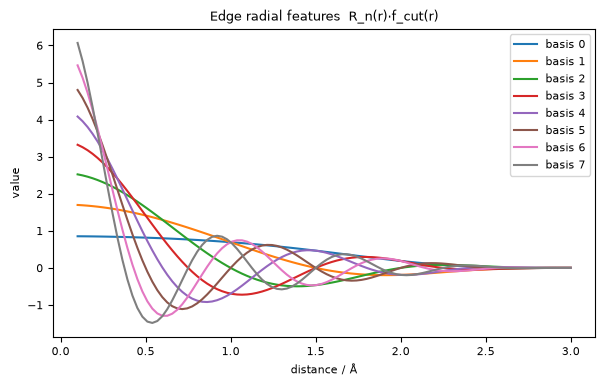

In [11]:
dists = torch.linspace(0.1, CUTOFF, 100).unsqueeze(-1)
radials, _ = mmodel.radial_embedding(dists, None, None, None)
plt.figure(figsize=(7, 4))
for i in range(radials.shape[1]):
    plt.plot(dists.squeeze(), radials[:, i].detach(), label=f"basis {i}")
plt.title("Edge radial features  R_n(r)·f_cut(r)")
plt.xlabel("distance / Å"); plt.ylabel("value"); plt.legend(fontsize=8); plt.show()

## 2. Interaction: pooling over neighbours

<img src="figures/interaction_first_layer.png" alt="The interaction block (first layer)"/>

The **interaction** pools information from an atom's neighbours into a 2-body
*atomic basis* $A_{i,klm}^{(t)}$, while tracking every array's $(l,m)$ indices.
Schematically, for atom $i$ at layer $t$:

$$ A_{i,klm}^{(t)} \;=\; \sum_{j \,\in\, \mathcal{N}(i)}
   R_{kl}(r_{ij})\;\, Y_l^m(\hat{\mathbf r}_{ij})\;\, h^{(t-1)}_{j,k}, $$

pooled (summed) over the neighbours and then normalised by `avg_num_neighbors`.

**Symbols.** $\mathcal{N}(i)$: the neighbours $j$ of atom $i$ within the cutoff;
$h^{(t-1)}_{j,k}$: the (previous-layer) features of neighbour $j$ in channel $k$;
$Y_l^m(\hat{\mathbf r}_{ij})$: spherical harmonics of the edge direction; $R_{kl}(r_{ij})$:
a **learnable radial function**, one per channel–degree pair $(k,l)$, produced by
passing the Bessel edge features through a small MLP (the *radial MLP*). The product
$R_{kl}\,Y_l^m$ is exactly the weighted tensor product of §"Spherical tensors", so $A$
stays a proper spherical tensor. It is called *2-body* because each term involves atom
$i$ and a single neighbour $j$.

We run `mace-torch`'s and `xnns`'s interaction blocks on the *same* embeddings and
compare the resulting atomic basis $A$ and the residual self-connection $sc$ (a learnable
shortcut of the atom's own features, added back later in the product block).

In [12]:
xI, mI = xfull.interactions[0], mmodel.interactions[0]

xA, xsc = xI(na, h0x, edge["edge_sh"], edge["edge_radial"], graph.edge_index)
mA, msc = mI(node_attrs=na, node_feats=h0x, edge_attrs=edge["edge_sh"],
             edge_feats=edge["edge_radial"], edge_index=graph.edge_index, cutoff=None)

report("interaction message  A", (xA - mA).abs().max().item())
report("residual self-connection  sc", (xsc - msc).abs().max().item())
print("A shape (atoms, channels, dim SH):", tuple(xA.shape))

OK interaction message  A                     max|xnns - mace| = 0.00e+00
OK residual self-connection  sc               max|xnns - mace| = 0.00e+00
A shape (atoms, channels, dim SH): (9, 8, 9)


We can visualise the *learnable radial functions*: the output of the radial MLP,
one function of distance per tensor-product weight. Untrained they are just smooth
random curves; training shapes them.

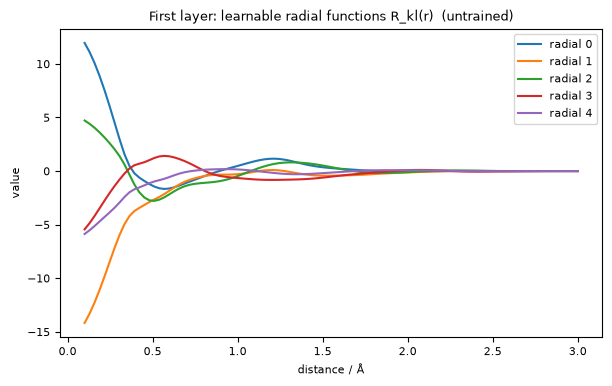

In [13]:
ef, _ = mmodel.radial_embedding(dists, None, None, None)
tp_w = mmodel.interactions[0].conv_tp_weights(ef).detach()
plt.figure(figsize=(7, 4))
for i in range(5):
    plt.plot(dists.squeeze(), tp_w[:, i], label=f"radial {i}")
plt.title("First layer: learnable radial functions R_kl(r)  (untrained)")
plt.xlabel("distance / Å"); plt.ylabel("value"); plt.legend(fontsize=8); plt.show()

## 3. Product: building many-body features

<img src="figures/product_layer.png" alt="The equivariant product block"/>

This is the heart of MACE. The product block raises the **body order** of the
features by multiplying $\nu$ copies of the atomic basis $A$ together and re-coupling
them into a proper spherical tensor with generalised Clebsch–Gordan coefficients:

$$ B^{(t)}_{i,\eta_\nu k L M} \;=\;
   \sum_{l_1 m_1}\cdots\sum_{l_\nu m_\nu}
   \mathcal{C}^{L M}_{\eta_\nu,\, l_1 m_1 \dots l_\nu m_\nu}\;
   \prod_{\xi=1}^{\nu} A^{(t)}_{i,\,k\, l_\xi m_\xi}. $$

**Symbols.** $A^{(t)}_{i,klm}$: the 2-body atomic basis from the interaction (atom $i$,
channel $k$, degree $l$, order $m$); $\nu$: the **correlation order** (`correlation`),
i.e. how many copies of $A$ are multiplied together (the resulting feature is
$(\nu+1)$-body); $\xi = 1,\dots,\nu$: the product index over those copies, each with its
own degree/order $(l_\xi, m_\xi)$; $L, M$: the degree and order of the **output** feature
$B$; $\mathcal{C}^{LM}_{\eta_\nu, \dots}$: the **generalised Clebsch–Gordan coefficients**
(the "$U$ tensors") that combine the $\nu$ inputs into something that transforms like a
single degree-$L$ object; $\eta_\nu$: an index enumerating the distinct symmetric
coupling *paths* that yield the same output $(L,M)$; $B^{(t)}_{i,\eta_\nu kLM}$: the
resulting many-body feature. A final linear layer mixes the paths $\eta_\nu$ and channels
$k$, and the self-connection $sc$ is added, producing the updated node features
$h^{(t)}_i$.

`xnns` implements the same **learned symmetric contraction** as `mace-torch`: its
Clebsch–Gordan $U$ basis is bit-identical and the contraction reproduces `mace-torch` to
~1e-16 given the same weights (verified in `tests/test_mace.py`). This is precisely the
piece the *old* `xnns` MACE only approximated (with a plain `TensorSquare`).

In [14]:
# symmetric contraction of A (nu copies) + linear mix + self-connection sc  ->  h^(1)
xB = xfull.products[0](xA, xsc, na)                    # args: (atomic basis A, self-connection sc, node_attrs)
mB = mmodel.products[0](node_feats=mA, node_attrs=na, sc=msc)
report("product + update  h^(1)", (xB - mB).abs().max().item())
# last dim = (max_L + 1)^2 * num_channels = (1+1)^2 * 8 = 4 * 8 = 32
print("h^(1) shape (atoms, (max_L+1)^2 · channels):", tuple(xB.shape), "= (N, 4·8)")

OK product + update  h^(1)                    max|xnns - mace| = 0.00e+00
h^(1) shape (atoms, (max_L+1)^2 · channels): (9, 32) = (N, 4·8)


The last dimension is $32 = 8 \times 4$: 8 channels times the 4 components of the
retained $l=0$ and $l=1$ features. Whether higher-$l$ (equivariant) features are kept
between layers is set by `max_L` (here `max_L=1`). The first 8 values (the $l=0$ part)
are invariant; the rest are equivariant and rotate with the molecule.

## 4. Readout: features → site energy

<img src="figures/readout.png" alt="The readout block"/>

The readout maps the **invariant** ($l=0$) part of the node features to a per-atom
site-energy contribution. Early layers use a simple linear map; the final layer uses a
small gated MLP:

$$ \mathcal{R}^{(t)}\!\left(h_i^{(t)}\right) \;=\;
   \begin{cases}
     \displaystyle\sum_{k} W_k^{(t)}\, h^{(t)}_{i,k00} & \text{if } t < T, \\[10pt]
     \mathrm{MLP}\!\left(\{\, h^{(t)}_{i,k00} \,\}_k\right) & \text{if } t = T.
   \end{cases} $$

**Symbols.** $\mathcal{R}^{(t)}$: the readout at layer $t$; $T$: the total number of
layers (`num_interactions`); $h^{(t)}_{i,k00}$: the invariant (degree $l=0$) part of
atom $i$'s features in channel $k$ (only the scalar part enters, so the site energy is
rotation-invariant); $W_k^{(t)}$: learnable linear weights; $\mathrm{MLP}$: a
one-hidden-layer perceptron with a SiLU gate (`gate`), used only at the last layer. The
output is $E_i^{(t)}$, the layer-$t$ site-energy contribution of atom $i$.

In [15]:
xe = xfull.readouts[0](xB).squeeze(-1)
me = mmodel.readouts[0](mB).squeeze(-1)
report("layer-0 readout (site energy)", (xe - me).abs().max().item())
print("per-atom energy contribution (layer 0):\n", xe.detach().numpy())

OK layer-0 readout (site energy)              max|xnns - mace| = 0.00e+00
per-atom energy contribution (layer 0):
 [0.34936828 0.33550752 0.41893127 0.33609633 0.3555528  0.3555528
 0.37259495 0.37439018 0.37439018]


## 5. Repeat: the whole model, end to end

Interaction → product → readout repeats for each layer, and all site energies are
summed together with the per-element reference $E_0$ to give the total energy; forces
are its gradient w.r.t. positions. Here we let **each package run its own full data
pipeline and forward pass independently**, then compare: the real end-to-end test.

In [16]:
# xnns: graph -> energy + forces
ox  = xmodel(graph)
E_x = float(ox["energy"]); F_x = ox["forces"].detach().numpy()

# mace: its own batch -> energy + forces
om  = mmodel(mbatch.to_dict(), compute_force=True)
E_m = float(om["energy"]); F_m = om["forces"].detach().numpy()

print(f"total energy   xnns = {E_x:.10f} eV")
print(f"total energy   mace = {E_m:.10f} eV\n")
report("FULL MODEL  total energy", abs(E_x - E_m))
report("FULL MODEL  per-atom forces", np.abs(F_x - F_m).max())

total energy   xnns = -14.6911114202 eV
total energy   mace = -14.6911114202 eV

OK FULL MODEL  total energy                   max|xnns - mace| = 1.78e-15
OK FULL MODEL  per-atom forces                max|xnns - mace| = 5.69e-16


**Energy and forces agree to ~1e-15**: `xnns` reproduces `mace-torch` to machine
precision, using only `e3nn`. That is the whole point: the same physics, re-expressed on
the `xnns` abstractions (`AtomicGraph`, featurizers, `ForceStressOutput`).

# The interaction block in more detail (second layer)

<img src="figures/interaction_layer_second.png" alt="The general interaction block, layer s"/>

At the **second** layer the interaction is harder, because the incoming node
features are no longer just scalars; they carry $(l,m)$ indices (we kept `max_L=1`).
The learnable radial functions now feed a richer tensor product, so the radial MLP must
output **more** weights than in the first layer. We can see this directly:

layer 0: radial MLP outputs 24 tensor-product weights
layer 1: radial MLP outputs 56 tensor-product weights


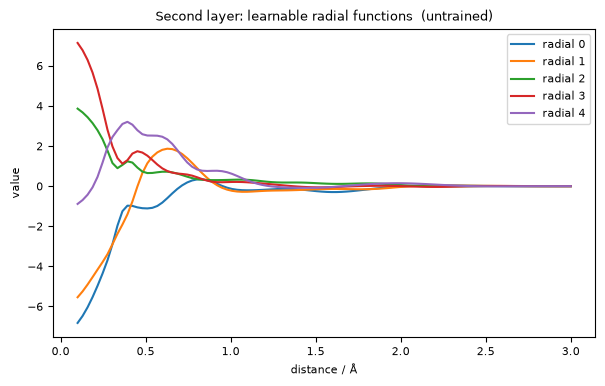

In [17]:
for layer in (0, 1):
    n_w = mmodel.interactions[layer].conv_tp_weights(ef).shape[1]
    print(f"layer {layer}: radial MLP outputs {n_w} tensor-product weights")

# the layer-1 learnable radials
tp_w1 = mmodel.interactions[1].conv_tp_weights(ef).detach()
plt.figure(figsize=(7, 4))
for i in range(5):
    plt.plot(dists.squeeze(), tp_w1[:, i], label=f"radial {i}")
plt.title("Second layer: learnable radial functions  (untrained)")
plt.xlabel("distance / Å"); plt.ylabel("value"); plt.legend(fontsize=8); plt.show()

> **`xnns` bonus.** In the original MACE `num_interactions` is fixed to 2; in `xnns`
> it is fully flexible, `T = 0 … N`. `T = 0` is a pure $E_0$ / pair-repulsion baseline,
> and any `T ≥ 1` stacks the interaction/product/readout above exactly as shown here.

## Summary

We rebuilt MACE block by block in **both** the original `mace-torch` and `xnns`, and
verified agreement at every stage:

| block | equation | `max\|xnns − mace\|` |
|---|---|---|
| node embedding | $h^{(0)} = W\,\theta$ | 0 |
| radial embedding | $R_n(r)\,f_{\rm cut}(r)$ | ~1e-15 |
| spherical harmonics | $Y_l^m(\hat r_{ij})$ | ~1e-15 |
| interaction | 2-body message $A$ | ~1e-16 |
| product | symmetric contraction $B$ | ~1e-16 |
| readout | site energy | ~1e-16 |
| **full model** | **energy & forces** | **~1e-15** |

`xnns` reuses the same equivariant maths as MACE (real Clebsch–Gordan coupling, learned
symmetric contraction) with **no `mace-torch` dependency** (only `e3nn`) and slots it
into the shared `xnns` abstractions so data loading, autograd forces/stress, training,
and ASE/LAMMPS deployment are identical across every model in the package.

**Where next.**
- `../../fidelity_checks/mace_verification.ipynb`: the same comparison at the level of
  individual `e3nn` blocks and the Clebsch–Gordan `U` tensors.
- `mace_argon_train_test.ipynb`: a full train/test pipeline, `xnns` vs `mace-torch`.
- `mace_argon_density_md.ipynb`: liquid-Argon density from NPT MD.